In [1]:
import pandas as pd
from joblib import load
from sklearn.metrics import *
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["Microsoft JhengHei"]

In [2]:
data = pd.read_csv(r'D:\Python\我的AI作品集\專案1_數學函數辨識\data\v2\function_dataset_merged_v2.csv')

In [3]:
X = data.drop(['label'], axis=1)
y = data['label']

In [4]:
train_rows = int(len(data)*0.8)
X_train = X.iloc[:train_rows].copy()
X_test = X.iloc[train_rows:].copy()
y_train = y.iloc[:train_rows].copy()
y_test = y.iloc[train_rows:].copy()

In [5]:
# 載入最終模型
model_package = load(r'D:\Python\我的AI作品集\專案1_數學函數辨識\models\v2\final_model_v2.joblib')

In [6]:
final_model = model_package['model']
feature_names = model_package['feature_names']

In [7]:
train_pred = final_model.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)
test_pred = final_model.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

In [8]:
print("----V2 最終結果----")
print(f"訓練數據準確度: {train_acc:.4f}")
print(f"測試數據準確度: {test_acc:.4f}")

----V2 最終結果----
訓練數據準確度: 1.0000
測試數據準確度: 0.8250


In [9]:
print(f"混淆矩陣:\n{confusion_matrix(y_test, test_pred)}\n")

混淆矩陣:
[[85  0  1  0  1  0  1 12]
 [ 0 76  5  0  0 16  0  3]
 [ 1  5 54 13  6 17  4  0]
 [ 0  0  7 85  6  2  0  0]
 [ 0  0  1  3 94  0  2  0]
 [ 1  6  3  6  0 84  0  0]
 [ 0  0  5  0  1  0 94  0]
 [ 9  0  0  0  0  0  3 88]]



In [10]:
labels = ["linear", "quadratic", "cubic", "exponential", "logarithmic", "sine", "cosine", "reciprocal"]

C:\Users\user\AppData\Local\Temp\ipykernel_24544\1020064714.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


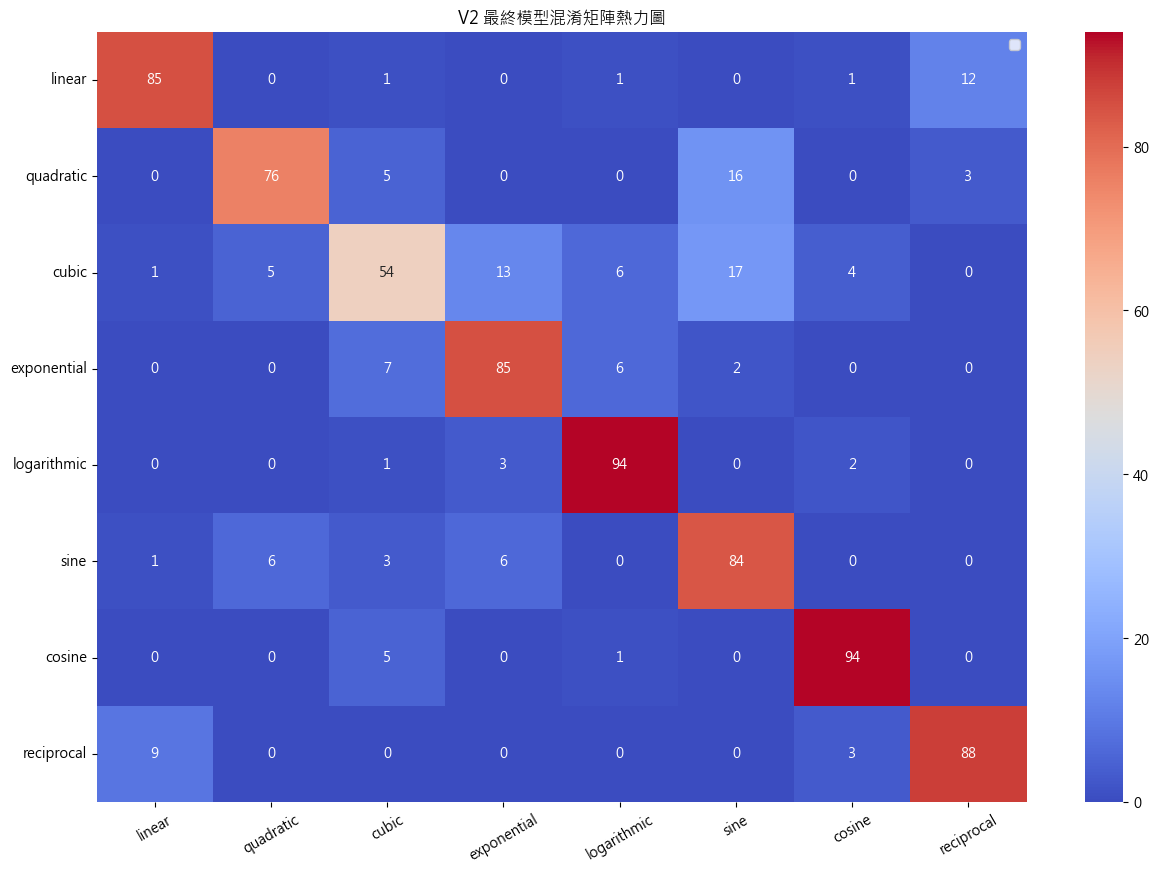

In [11]:
plt.figure(figsize=(15, 10))
sns.heatmap(confusion_matrix(y_test, test_pred), 
            cmap='coolwarm', 
            xticklabels=[i for i in labels], 
            yticklabels=[i for i in labels],
            annot=True)
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.title('V2 最終模型混淆矩陣熱力圖')
plt.legend()
plt.savefig(r'D:\Python\我的AI作品集\專案1_數學函數辨識\data\v2\final_confusion_matrix_v2.png')
plt.show()

In [12]:
print(f"分類報告:\n{classification_report(y_test, test_pred)}\n")

分類報告:
              precision    recall  f1-score   support

      cosine       0.89      0.85      0.87       100
       cubic       0.87      0.76      0.81       100
 exponential       0.71      0.54      0.61       100
      linear       0.79      0.85      0.82       100
 logarithmic       0.87      0.94      0.90       100
   quadratic       0.71      0.84      0.77       100
  reciprocal       0.90      0.94      0.92       100
        sine       0.85      0.88      0.87       100

    accuracy                           0.82       800
   macro avg       0.82      0.82      0.82       800
weighted avg       0.82      0.82      0.82       800


